# 폐업률 ↔ 유동인구 감소율 분석 (코로나 구간)
- 목적: 유동인구가 줄어든 구간에서 폐업률도 함께 높아지는지 확인
- 데이터: 나경(상권변화지표) × 정연(길단위인구)
- 분석 기간: 2019Q1 ~ 2024Q4

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 데이터 불러오기

In [2]:
# 상권변화지표 데이터 불러오기
df_상권 = pd.read_csv(
    "../data/08_상권변화지표/서울시 상권분석서비스(상권변화지표-상권).csv",
    encoding="cp949"
)

# 길단위인구 데이터 불러오기
df_인구 = pd.read_csv(
    "../data/05_길단위인구/서울시 상권분석서비스(길단위인구-상권).csv",
    encoding="cp949"
)

# 분석 기간 필터링 (2019~2024)
df_상권 = df_상권[df_상권['기준_년분기_코드'] < 20250]
df_인구 = df_인구[df_인구['기준_년분기_코드'] < 20250]

print(f"상권변화지표: {df_상권.shape}")
print(f"길단위인구: {df_인구.shape}")
print(f"\n길단위인구 컬럼: {df_인구.columns.tolist()}")

상권변화지표: (39600, 11)
길단위인구: (39589, 27)

길단위인구 컬럼: ['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수', '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수', '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수', '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수', '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수']


## 소희님 점포 데이터 불러오기

In [4]:
# 소희님 점포 합본 불러오기
df_점포 = pd.read_csv(
    "../data/점포_합본.csv",
    encoding='utf-8-sig'
)

print(f"점포 데이터: {df_점포.shape}")
print(f"컬럼: {df_점포.columns.tolist()}")

점포 데이터: (1831925, 15)
컬럼: ['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '점포_수', '유사_업종_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수', '연도']


## 데이터 전처리
- 점포 데이터: 연도+상권 기준으로 집계 (업종별 → 상권별)
- 세 데이터 합치기

In [5]:
# 점포 데이터 연도+상권 기준으로 집계
df_점포_집계 = df_점포.groupby(['연도', '상권_코드', '상권_구분_코드_명']).agg(
    총점포수=('점포_수', 'sum'),
    총개업수=('개업_점포_수', 'sum'),
    총폐업수=('폐업_점포_수', 'sum')
).reset_index()

# 폐업률 계산
df_점포_집계['폐업률'] = (df_점포_집계['총폐업수'] / df_점포_집계['총점포수'] * 100).round(2)

print(f"집계 후 점포 데이터: {df_점포_집계.shape}")
print(df_점포_집계.head())

집계 후 점포 데이터: (9900, 7)
     연도    상권_코드 상권_구분_코드_명   총점포수  총개업수  총폐업수   폐업률
0  2019  3001491       관광특구   6421   255   228  3.55
1  2019  3001492       관광특구  35239  1070   868  2.46
2  2019  3001493       관광특구  58503  2245  1368  2.34
3  2019  3001494       관광특구  18037   437   441  2.44
4  2019  3001495       관광특구  10788   568   317  2.94


## 세 데이터 합치기
- 연도 + 상권_코드 기준으로 연결

In [6]:
# 유동인구 연도 컬럼 추가
df_인구['연도'] = df_인구['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 유동인구 연도+상권 기준으로 집계
df_인구_집계 = df_인구.groupby(['연도', '상권_코드', '상권_구분_코드_명']).agg(
    평균_유동인구=('총_유동인구_수', 'mean')
).reset_index()

# 점포 + 유동인구 합치기
df_합 = pd.merge(
    df_점포_집계,
    df_인구_집계[['연도', '상권_코드', '평균_유동인구']],
    on=['연도', '상권_코드'],
    how='inner'
)

print(f"합친 데이터: {df_합.shape}")
print(df_합.head())

합친 데이터: (9899, 8)
     연도    상권_코드 상권_구분_코드_명   총점포수  총개업수  총폐업수   폐업률      평균_유동인구
0  2019  3001491       관광특구   6421   255   228  3.55   2438319.00
1  2019  3001492       관광특구  35239  1070   868  2.46   8164084.00
2  2019  3001493       관광특구  58503  2245  1368  2.34   3820540.75
3  2019  3001494       관광특구  18037   437   441  2.44  10669713.25
4  2019  3001495       관광특구  10788   568   317  2.94   3760889.75


## 연도별 폐업률 vs 유동인구 변화율 계산
- 상권 유형별로 연도별 평균 계산
- 유동인구 변화율: 전년도 대비 증감률

In [7]:
# 연도별 상권유형별 평균 계산
연도별 = df_합.groupby(['연도', '상권_구분_코드_명']).agg(
    폐업률=('폐업률', 'mean'),
    평균_유동인구=('평균_유동인구', 'mean')
).reset_index()

# 유동인구 전년도 대비 변화율 계산
연도별['유동인구_변화율'] = 연도별.groupby('상권_구분_코드_명')['평균_유동인구'].pct_change() * 100

print(연도별.round(2))

      연도 상권_구분_코드_명   폐업률     평균_유동인구  유동인구_변화율
0   2019       골목상권  3.01   881415.37       NaN
1   2019       관광특구  2.53  4829419.42       NaN
2   2019       발달상권  3.01  1409800.42       NaN
3   2019       전통시장  3.06   373185.92       NaN
4   2020       골목상권  2.83   885889.80      0.51
5   2020       관광특구  2.72  3848501.67    -20.31
6   2020       발달상권  2.92  1288536.28     -8.60
7   2020       전통시장  3.03   346705.27     -7.10
8   2021       골목상권  2.89   856691.60     -3.30
9   2021       관광특구  2.62  3760862.58     -2.28
10  2021       발달상권  2.74  1257003.12     -2.45
11  2021       전통시장  2.71   332862.66     -3.99
12  2022       골목상권  2.67   845069.32     -1.36
13  2022       관광특구  2.02  4161715.21     10.66
14  2022       발달상권  2.56  1321929.19      5.17
15  2022       전통시장  2.53   334318.70      0.44
16  2023       골목상권  3.18   832137.37     -1.53
17  2023       관광특구  2.29  4234286.50      1.74
18  2023       발달상권  2.87  1340757.10      1.42
19  2023       전통시장  2.87   330248.41   

## 연도별 폐업률 vs 유동인구 변화율 시각화
- 상권 유형별로 두 지표 비교
- 코로나(2020), 위드코로나(2022) 시점 표시

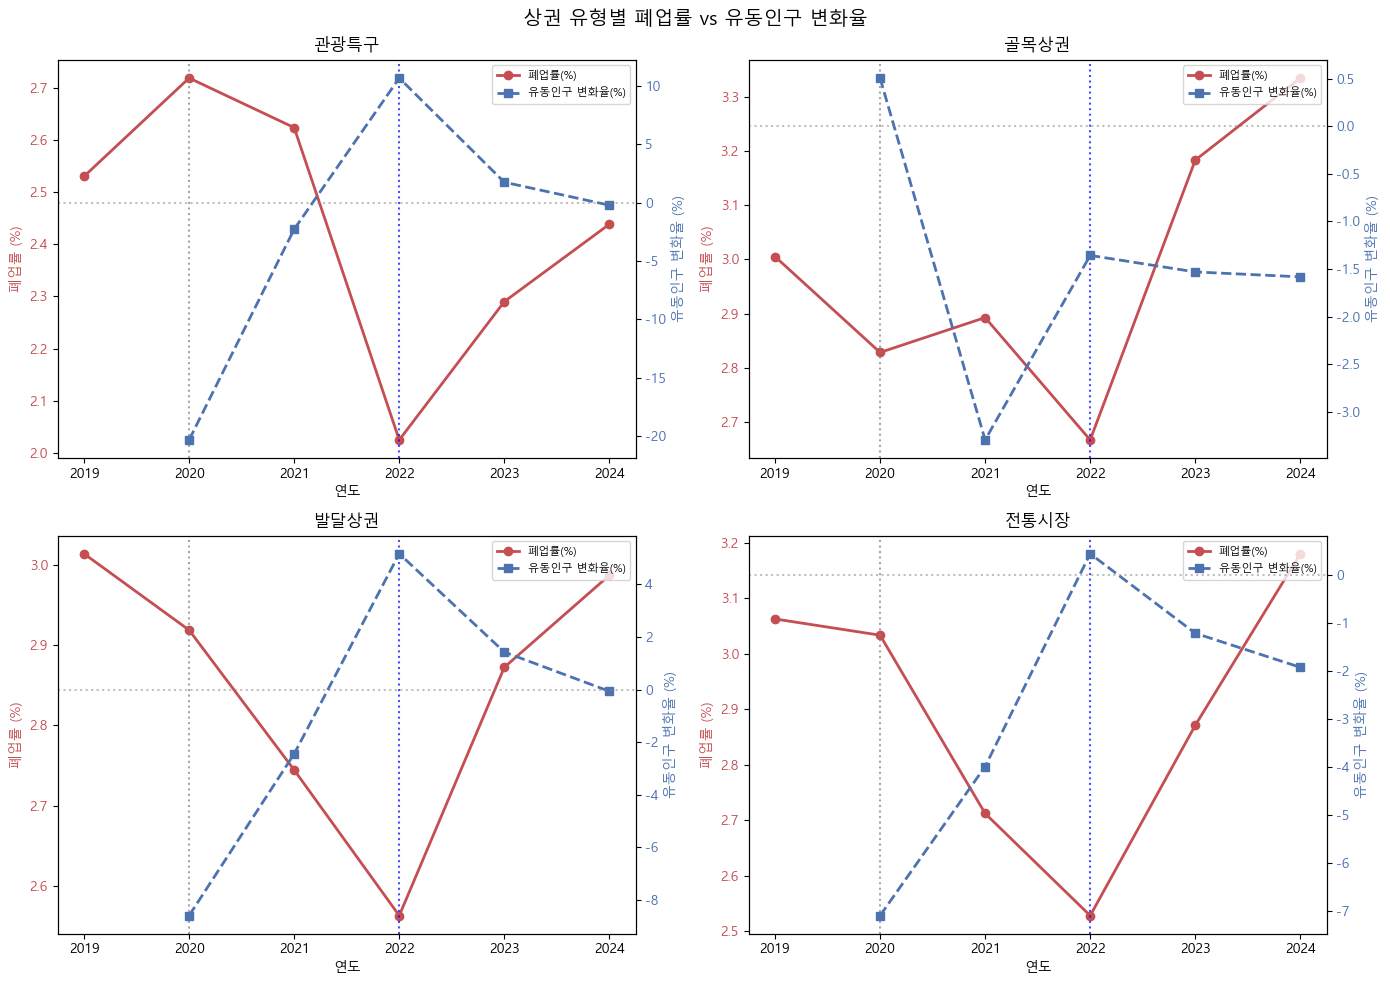

In [9]:
# 2행 2열로 4개 그래프 칸 만들기 (상권 유형 4개니까)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 2x2 배열을 [0,1,2,3] 1줄로 펴기 (순서대로 접근하기 위해)
axes = axes.flatten()

# 분석할 상권 유형 목록
상권_목록 = ['관광특구', '골목상권', '발달상권', '전통시장']

# 상권 유형별로 하나씩 그래프 그리기
for i, 유형 in enumerate(상권_목록):
    # 해당 유형만 필터링
    df_유형 = 연도별[연도별['상권_구분_코드_명'] == 유형]
    
    # i번째 칸 선택
    ax1 = axes[i]
    # 같은 칸에 오른쪽 축 추가 (단위가 다른 두 지표를 같이 보기 위해)
    ax2 = ax1.twinx()
    
    # 왼쪽 축: 폐업률 (빨간선)
    ax1.plot(df_유형['연도'], df_유형['폐업률'],
             marker='o', color='#C44E52', linewidth=2, label='폐업률(%)')
    ax1.set_ylabel('폐업률 (%)', color='#C44E52')
    ax1.tick_params(axis='y', labelcolor='#C44E52')
    
    # 오른쪽 축: 유동인구 변화율 (파란선)
    ax2.plot(df_유형['연도'], df_유형['유동인구_변화율'],
             marker='s', color='#4C72B0', linewidth=2, linestyle='--', label='유동인구 변화율(%)')
    ax2.set_ylabel('유동인구 변화율 (%)', color='#4C72B0')
    ax2.tick_params(axis='y', labelcolor='#4C72B0')
    # 변화율 0% 기준선 표시
    ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    
    # 코로나 시점 세로선
    ax1.axvline(x=2020, color='gray', linestyle=':', alpha=0.7)
    ax1.axvline(x=2022, color='blue', linestyle=':', alpha=0.7)
    
    # 그래프 제목 (상권 유형명)
    ax1.set_title(f'{유형}', fontsize=12)
    ax1.set_xlabel('연도')
    
    # 두 축의 범례 합치기
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

# 전체 제목
plt.suptitle('상권 유형별 폐업률 vs 유동인구 변화율', fontsize=14)
plt.tight_layout()
plt.show()